-----------------------------------------------CHARGER LES DONNEES-----------------------------------

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"D:/Projet 4/TaxiOut AI/data/year=2008/day_of_week=Friday/part-00054-457d7a39-f2d7-477b-889a-1a5e13ece90d.c000.snappy.parquet"

df = pd.read_parquet(path)

print(df.shape)

(350566, 29)


------------------------SUPPRIMER LES VOLS ANNULES----------------------------------------------------------------

In [38]:
df = df[df["cancelled"] == 0]

---------------------------------------------SUPPRIMER LES COLONNES INUTILES---------------------------------

In [39]:
columns_to_drop = [
    "index",
    "plane_tail_number",
    "cancellation_code"
]

df.drop(columns=columns_to_drop, inplace=True)

--------------------------------SUPPRIMER LES COLONNES DATA LEAKAGE----------------------------------


In [40]:
leakage_columns = [
    "actual_departure_time",
    "actual_arrival_time",
    "arrival_delay",
    "air_time",
    "actual_elapsed_time",
    "taxi_in"
]

df.drop(columns=leakage_columns, inplace=True)

---------------------------------TYPES DES DONNEES-----------------------------------------

In [41]:
print(df.dtypes)

month                         int32
day_of_month                  int32
scheduled_departure_time      int32
scheduled_arrival_time        int32
unique_carrier               object
flight_number                 int32
scheduled_elapsed_time      float64
departure_delay             float64
origin                       object
dest                         object
distance                     object
taxi_out                    float64
cancelled                     int32
diverted                      int32
carrier_delay               float64
weather_delay               float64
nas_delay                   float64
security_delay              float64
late_aircraft_delay         float64
date                         object
dtype: object


----------------------------AFFICHAGE DE NOUVEAU STRUCTURE DE DONNEES ----------------------------------------------------------

In [42]:
df.shape

(339013, 20)

-------------------------------CONVERTIR DATE-------------------------------------------------

In [43]:
df["date"] = pd.to_datetime(df["date"])

------------------------------CONVERTIR TYPE DISTANCE  OBJET->NUMERIC -----------------------------------

In [44]:
df["distance"] = pd.to_numeric(df["distance"], errors="coerce")

-------------------------------VERFIER LES VALEURS NULLES-----------------------------------------------

In [45]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

carrier_delay             235688
weather_delay             235688
security_delay            235688
nas_delay                 235688
late_aircraft_delay       235688
scheduled_elapsed_time        41
dtype: int64


-------------------------------SUPPRIMER LES LIGNES QUI NE CONTIENT PAS TARGET "taxi_out"--------------------------------------

In [46]:
df = df[df["taxi_out"].notna()]

---------------------------------------VERFIER LES OUTLIERS "taxi_out"-----------------------------------------------

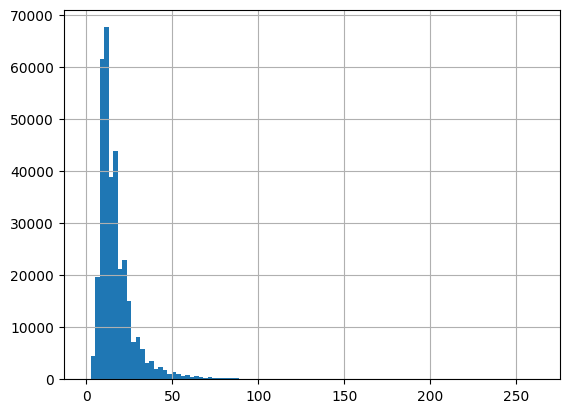

In [47]:
df["taxi_out"].hist(bins=100)

plt.show()

-------------------------------------STATISTIQUES DE TARGET "taxi_out"-------------------------------------------------

In [48]:
print(df["taxi_out"].describe())

count    339013.000000
mean         17.438517
std          12.174856
min           0.000000
25%          10.000000
50%          14.000000
75%          20.000000
max         262.000000
Name: taxi_out, dtype: float64
